In [6]:
#!/usr/bin/env python3
"""
Visual debugging for L1C cloud detection
"""

import ee
import numpy as np#!/usr/bin/env python3
"""
Debug cloud mask visually
"""

import ee
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from PIL import Image

import sys
import os

sys.path.append(os.path.join(os.path.dirname(os.getcwd()), '../../../'))
from src.features.download_sentinel2 import initialize_earthengine, custom_l1c_cloud_mask, get_quality_mask

initialize_earthengine()

Total images: 4

IMAGE 1: 2023-05-01
Custom cloud detector: 10.0% cloudy
Final quality mask: 0.0% good pixels
Decision: REJECT ✗


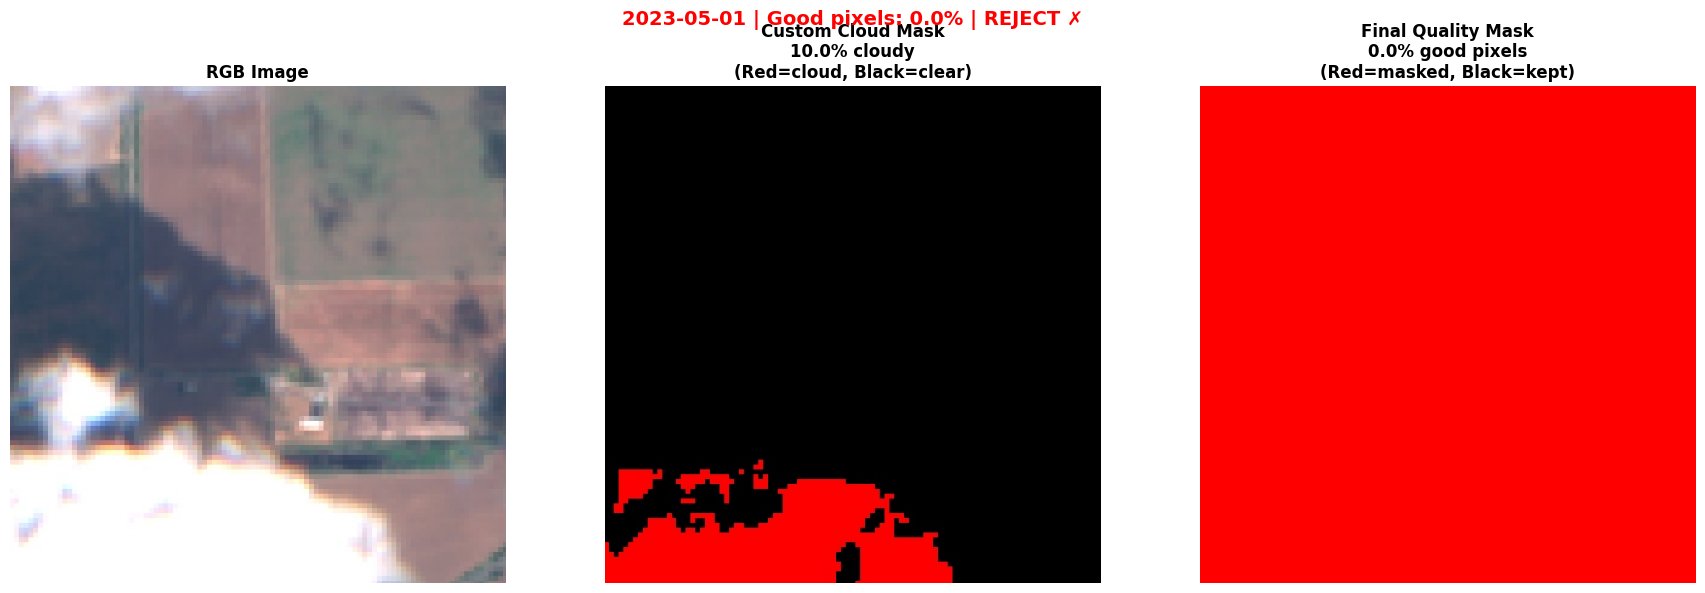


IMAGE 2: 2023-05-04
Custom cloud detector: 100.0% cloudy
Final quality mask: 0.0% good pixels
Decision: REJECT ✗


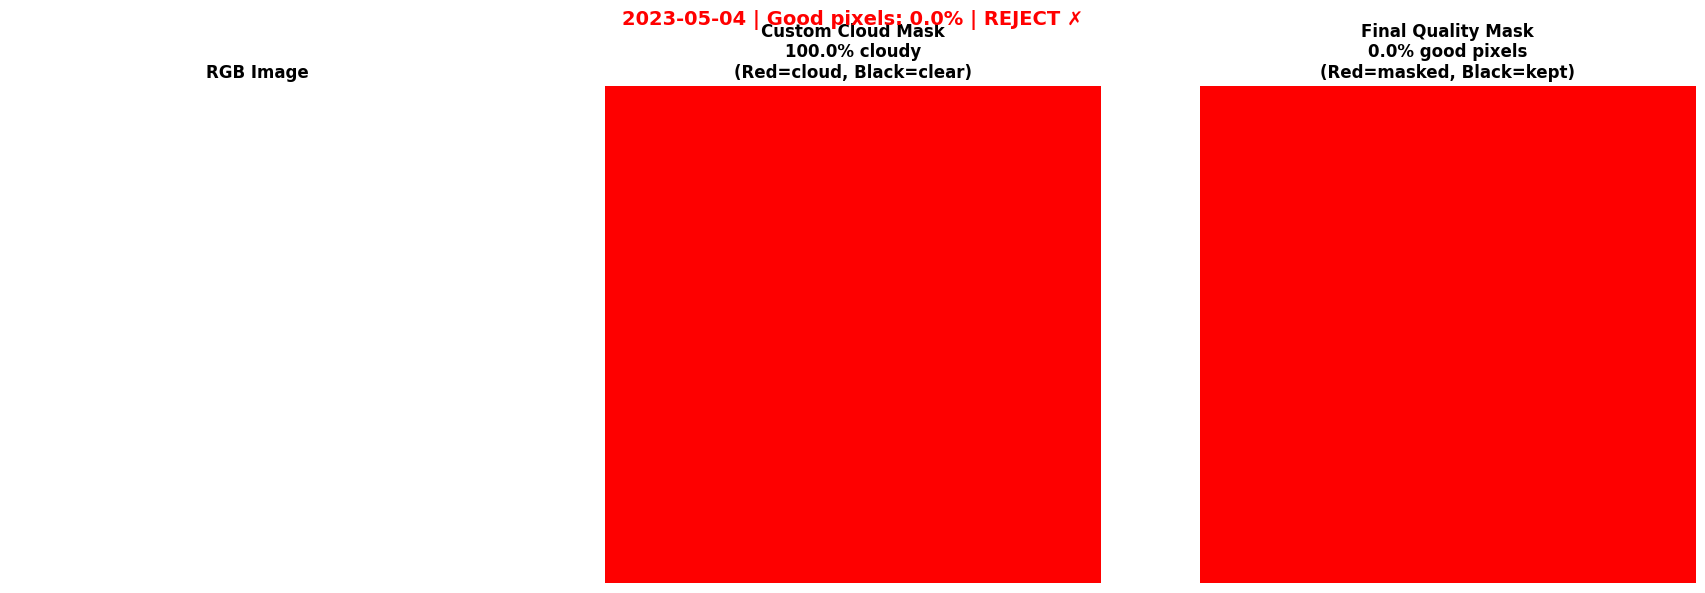


IMAGE 3: 2023-05-06
Custom cloud detector: 0.0% cloudy
Final quality mask: 0.0% good pixels
Decision: REJECT ✗


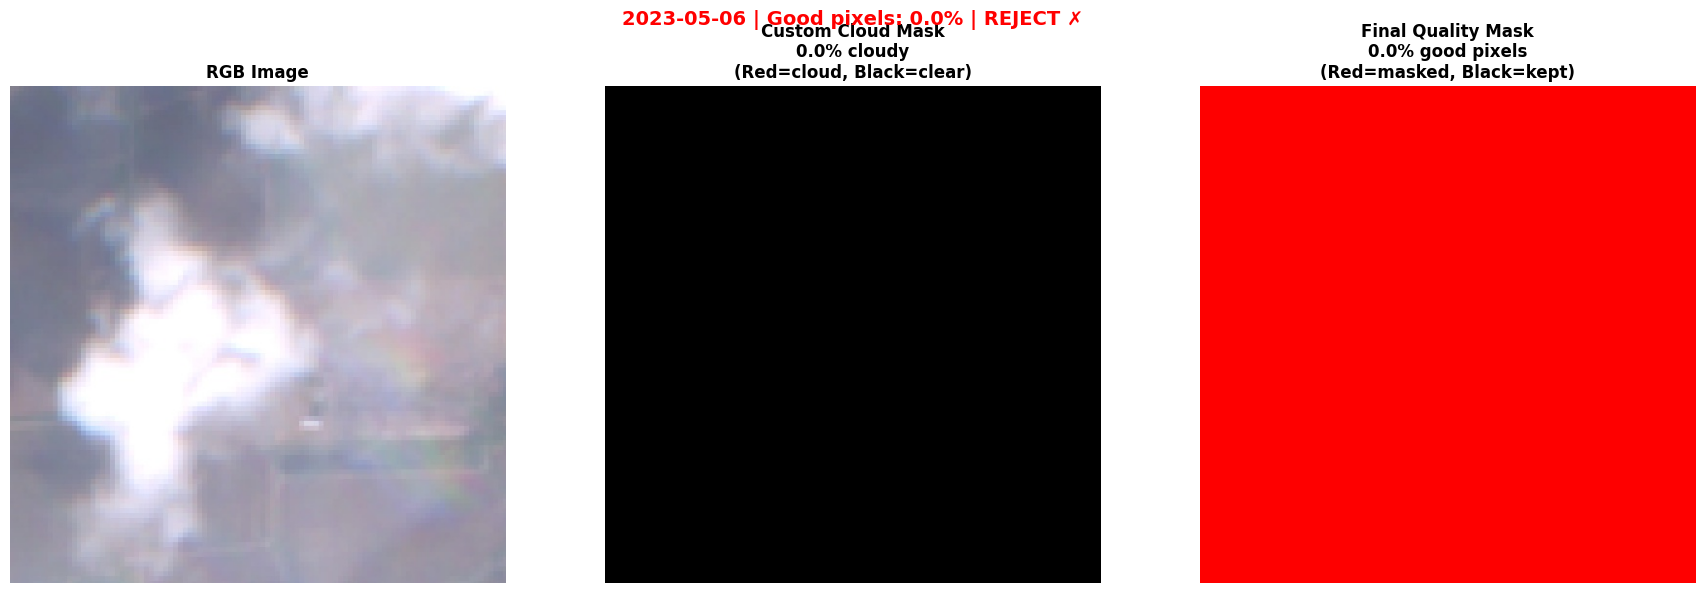


IMAGE 4: 2023-05-09
Custom cloud detector: 0.0% cloudy
Final quality mask: 100.0% good pixels
Decision: KEEP ✓


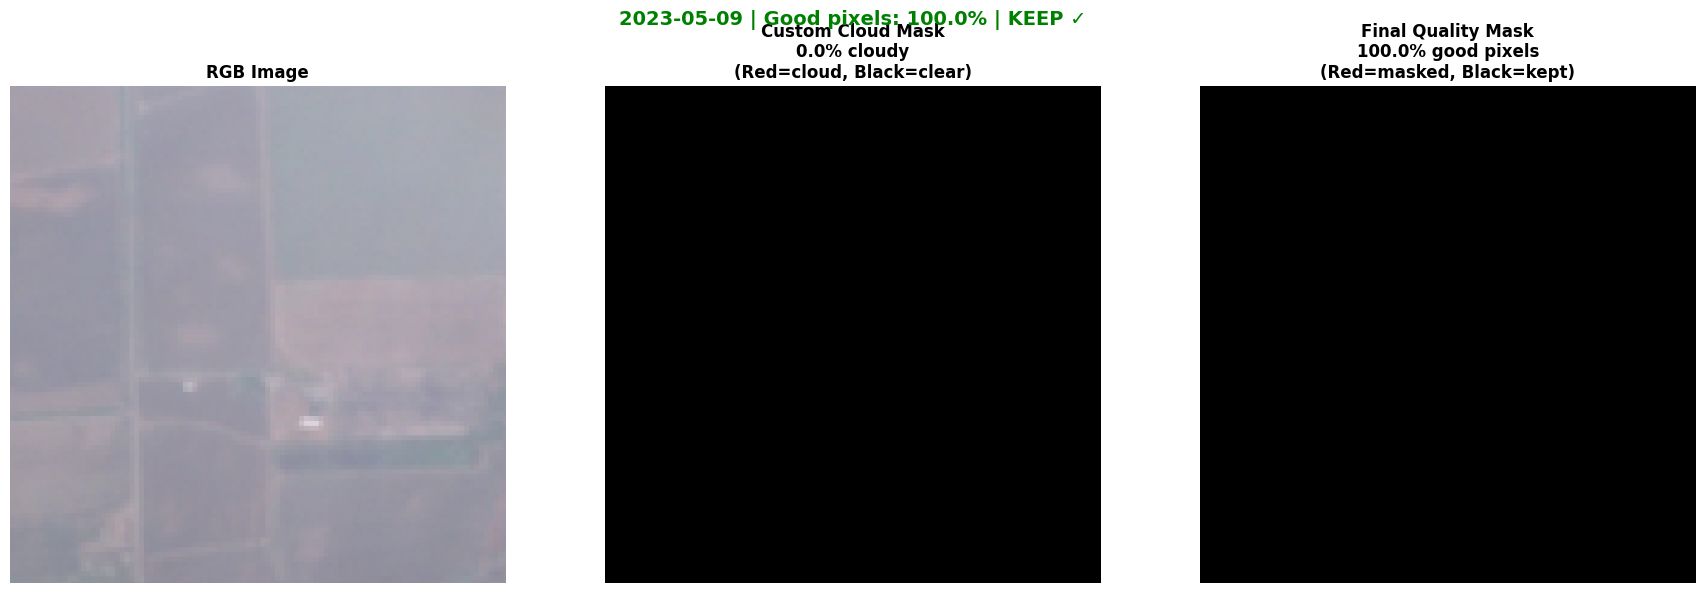

In [7]:
# Test case - cloudy image
lat = 37.5
lon = -120.5
start_date = '2023-05-01'
end_date = '2023-05-11'

point = ee.Geometry.Point([lon, lat])
region = point.buffer(500).bounds()

# Get collection
col = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED")
       .filterBounds(region)
       .filterDate(ee.Date(start_date), ee.Date(end_date)))

print(f"Total images: {col.size().getInfo()}")

# Test each image
for i in range(col.size().getInfo()):
    img = ee.Image(col.toList(col.size()).get(i))
    img_date = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd').getInfo()
    
    print(f"\n{'='*70}")
    print(f"IMAGE {i+1}: {img_date}")
    print('='*70)
    
    # Create masks
    custom_cloud_mask = custom_l1c_cloud_mask(img)  # 1 = cloud, 0 = clear
    quality_mask = get_quality_mask(img, "L1C")     # 1 = good, 0 = bad
    
    # Calculate statistics
    cloud_stats = custom_cloud_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=60,
        maxPixels=1e9
    ).getInfo()
    
    quality_stats = quality_mask.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=60,
        maxPixels=1e9
    ).getInfo()
    
    cloud_fraction = cloud_stats['cloud_mask']
    good_pixel_fraction = quality_stats['cloud_mask']
    
    print(f"Custom cloud detector: {cloud_fraction*100:.1f}% cloudy")
    print(f"Final quality mask: {good_pixel_fraction*100:.1f}% good pixels")
    print(f"Decision: {'REJECT ✗' if good_pixel_fraction < 0.85 else 'KEEP ✓'}")
    
    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Panel 1: RGB
    rgb_vis = img.visualize(bands=['B4','B3','B2'], min=0, max=3000)
    rgb_url = rgb_vis.getThumbURL({'region': region, 'dimensions': 512})
    rgb_img = Image.open(BytesIO(requests.get(rgb_url).content))
    axes[0].imshow(rgb_img)
    axes[0].set_title('RGB Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Panel 2: Custom cloud mask (before buffering)
    cloud_vis = custom_cloud_mask.visualize(min=0, max=1, palette=['black', 'red'])
    cloud_url = cloud_vis.getThumbURL({'region': region, 'dimensions': 512})
    cloud_img = Image.open(BytesIO(requests.get(cloud_url).content))
    axes[1].imshow(cloud_img)
    axes[1].set_title(f'Custom Cloud Mask\n{cloud_fraction*100:.1f}% cloudy\n(Red=cloud, Black=clear)', 
                     fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Panel 3: Final quality mask (after QA60 + custom + 2km buffering)
    # Invert for visualization: 1=good becomes 0=good for consistent coloring
    bad_pixels = quality_mask.Not()  # Now 1 = bad, 0 = good
    quality_vis = bad_pixels.visualize(min=0, max=1, palette=['black', 'red'])
    quality_url = quality_vis.getThumbURL({'region': region, 'dimensions': 512})
    quality_img = Image.open(BytesIO(requests.get(quality_url).content))
    axes[2].imshow(quality_img)
    axes[2].set_title(f'Final Quality Mask\n{good_pixel_fraction*100:.1f}% good pixels\n(Red=masked, Black=kept)', 
                     fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    fig.suptitle(f"{img_date} | Good pixels: {good_pixel_fraction*100:.1f}% | "
                f"{'REJECT ✗' if good_pixel_fraction < 0.85 else 'KEEP ✓'}",
                fontsize=14, fontweight='bold',
                color='red' if good_pixel_fraction < 0.85 else 'green')
    
    plt.tight_layout()
    plt.show()